In [15]:
from langgraph.graph import StateGraph, START , END
from langchain_ollama import OllamaLLM,ChatOllama
from typing import TypedDict, Annotated,Literal
from dotenv import load_dotenv
from langchain_core.messages import BaseMessage, HumanMessage
from pydantic import BaseModel, Field
import operator
from langgraph.checkpoint.memory import MemorySaver

In [3]:
from langgraph.graph.message import add_messages
class ChatState(TypedDict):

    messages: Annotated[list[BaseMessage],add_messages]

In [10]:
llm = ChatOllama(model="llama3")
def chat_node(state: ChatState):

    #take user qquery from state
    messages = state['messages']

    #send to llm
    response = llm.invoke(messages)

    #response store state
    return{'messages':[response]}

In [16]:
checkpointer = MemorySaver()
graph = StateGraph(ChatState)

graph.add_node('chat_node',chat_node)
graph.add_edge(START,'chat_node')
graph.add_edge('chat_node',END)

chatbot = graph.compile(checkpointer=checkpointer)

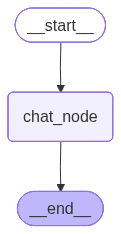

In [7]:
chatbot

In [11]:
inital_state = {
    'messages':[HumanMessage(content='What is the captial of India?')]
}
chatbot.invoke(inital_state)

{'messages': [HumanMessage(content='What is the captial of India?', additional_kwargs={}, response_metadata={}, id='e76f4ffe-bb10-4d19-bca7-f25d47f68600'),
  AIMessage(content='The capital of India is New Delhi.', additional_kwargs={}, response_metadata={'model': 'llama3', 'created_at': '2026-04-30T02:09:19.9409874Z', 'done': True, 'done_reason': 'stop', 'total_duration': 1426060900, 'load_duration': 123978600, 'prompt_eval_count': 18, 'prompt_eval_duration': 366580100, 'eval_count': 9, 'eval_duration': 926583700, 'logprobs': None, 'model_name': 'llama3', 'model_provider': 'ollama'}, id='lc_run--019ddc25-ceb1-7461-a035-c5bcae2fe673-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 18, 'output_tokens': 9, 'total_tokens': 27})]}

In [17]:
thread_id = '1'
while True:

    user_message = input('Type here: ')
    print('User: ',user_message)
    if user_message.strip().lower() in ['exit','quit','bye']:
        break
    
    config = {'configurable':{'thread_id':thread_id}}

    response = chatbot.invoke({'messages':[HumanMessage(content = user_message)]},config=config)

    print('AI: ', response['messages'][-1].content)

User:  hi my name is arjun
AI:  Hi Arjun! It's nice to meet you. What brings you here today? Do you have any specific questions or topics you'd like to discuss? I'm all ears!
User:  whats my name?
AI:  Your name is Arjun, right?
User:  yea you are right , my nickname is veer
AI:  That's cool! So your nickname is Veer, huh? Well, it's always nice to have a fun nickname to go along with your regular name. What's the story behind how you got the nickname Veer?
User:  can you tell me a link between my both names by their meaninng
AI:  Let's explore the meanings of Arjun and Veer.

Arjun is a Hindu name, derived from the Sanskrit word "Arya", meaning "noble" or "exalted". In Hindu mythology, Arjuna is one of the main characters in the epic poem Mahabharata. He was known for his bravery, loyalty, and moral integrity.

Veer (also spelled Veeru) is a Hindi/Sanskrit word that means "brave" or "heroic". It's often used as a nickname to express admiration and respect for someone's courage, streng

In [13]:
# the problem is we dont have the storage of past conversation history and memory 
# reason: the first message went to the end node and everything got erased , then next we gave 2nd message to start and the chatbot have no history cause its a other invocation flaw: we are invkoing again and again and we are starting fresh everytime

In [14]:
#solution : persistence-> aap chizo ko erase nahi k rte , aap store krte ho , either in ram or database ( we can use memory wala funda for now)

In [18]:
chatbot.get_state(config = config)

StateSnapshot(values={'messages': [HumanMessage(content='hi my name is arjun', additional_kwargs={}, response_metadata={}, id='12b4a2f5-913d-4e23-8ad1-5ea578703447'), AIMessage(content="Hi Arjun! It's nice to meet you. What brings you here today? Do you have any specific questions or topics you'd like to discuss? I'm all ears!", additional_kwargs={}, response_metadata={'model': 'llama3', 'created_at': '2026-04-30T02:22:34.1423934Z', 'done': True, 'done_reason': 'stop', 'total_duration': 12794690900, 'load_duration': 7120821700, 'prompt_eval_count': 16, 'prompt_eval_duration': 525182900, 'eval_count': 37, 'eval_duration': 5115370700, 'logprobs': None, 'model_name': 'llama3', 'model_provider': 'ollama'}, id='lc_run--019ddc31-c0a2-74c0-9d2d-f0247ba1d7c6-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 16, 'output_tokens': 37, 'total_tokens': 53}), HumanMessage(content='whats my name?', additional_kwargs={}, response_metadata={}, id='718a4069-b575-41be-847c-d636a62